In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


<h3>Data Preprocessing and Exploratory Data Analysis</h3>

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option("display.max_colwidth",500)

In [3]:
DATA_PATH = "/kaggle/input/competitions/smart-mcq-solver-challenge"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
test = pd.read_csv(f"{DATA_PATH}/test.csv")

In [4]:
print("Train Shape :", train.shape)
print("Test Shape :", test.shape)

train.head()

Train Shape : (2000, 8)
Test Shape : (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,"Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.","Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.","Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.",Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the future is predetermined. Human beings do not have free will.,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of this illusion and are guided by a higher power.",B
1,2,What is accelerator-based light-ion fusion?,"Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 10 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 100 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 100 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fission reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fission can be observed with as little as 10 kV between the electrodes.",A
2,3,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully.,"Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the f

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [6]:
train.describe(include='all')

,id,prompt,A,B,C,D,E,answer
count,2000.000000,2000,2000,2000,2000,2000,2000,2000
unique,NaN,1758,316,328,303,318,320,5
top,NaN,"Select the most accurate option: How do the Lunar Laser Ranging Experiment, radar astronomy, and the Deep Space Network determine distances to the Moon, planets, and spacecraft? carefully.","An improper rotation is the combination of a rotation about an axis and reflection in a plane perpendicular to that axis, or inversion about a point on the axis. The order of the rotation and reflection does not matter, and the symmetry elements for improper rotation are the rotation axis, and either the mirror plane, the inversion point, or both, and a third plane.","An improper rotation is the combination of a rotation about an axis and reflection in a plane perpendicular to that axis, or inversion about a point on the axis. The order of the rotation and reflection does not matter, and the symmetry elements for improper rotation are the rotation axis, and either the mirror plane, the inversion point, or both.","An improper rotation is the combination of a rotation about an axis and reflection in a plane parallel to that axis, or inversion about a point on the axis. The order of the rotation and reflection does not matter, and the symmetry elements for improper rotation are the rotation axis, and either the mirror plane, the inversion point, or neither.","An improper rotation is the combination of a rotation about an axis and reflection in a plane perpendicular to that axis, or inversion about a point on the axis. The order of the rotation and reflection does not matter, and the symmetry elements for improper rotation are the rotation axis, and either the mirror plane, the inversion point, or neither.","An improper rotation is the combination of a rotation about an axis and reflection in a plane parallel to that axis, or inversion about a point on the axis. The order of the rotation and reflection does not matter, and the symmetry elements for improper rotation are the rotation axis, and either the mirror plane, the inversion point, or both.",B
freq,NaN,4,21,21,21,21,21,490
mean,1000.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,577.494589,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,500.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1000.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1500.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
missing = train.isnull().sum()

missing

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [8]:
print("Duplicate Rows :", train.duplicated().sum())

Duplicate Rows : 0


In [9]:
train["prompt_length"] = train["prompt"].astype(str).apply(len)

for col in ['A','B','C','D','E']:
    train[f"{col}_length"] = train[col].astype(str).apply(len)

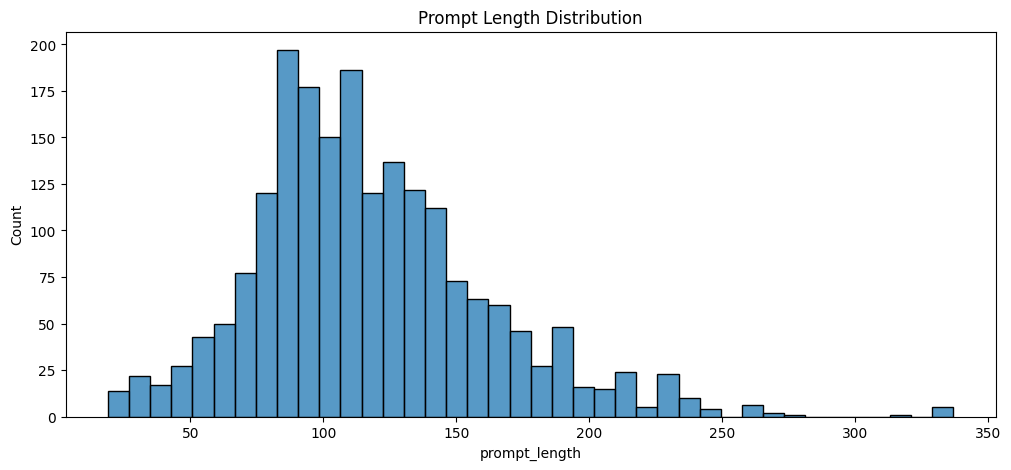

In [10]:
plt.figure(figsize=(12,5))

sns.histplot(train["prompt_length"], bins=40)

plt.title("Prompt Length Distribution")

plt.show()

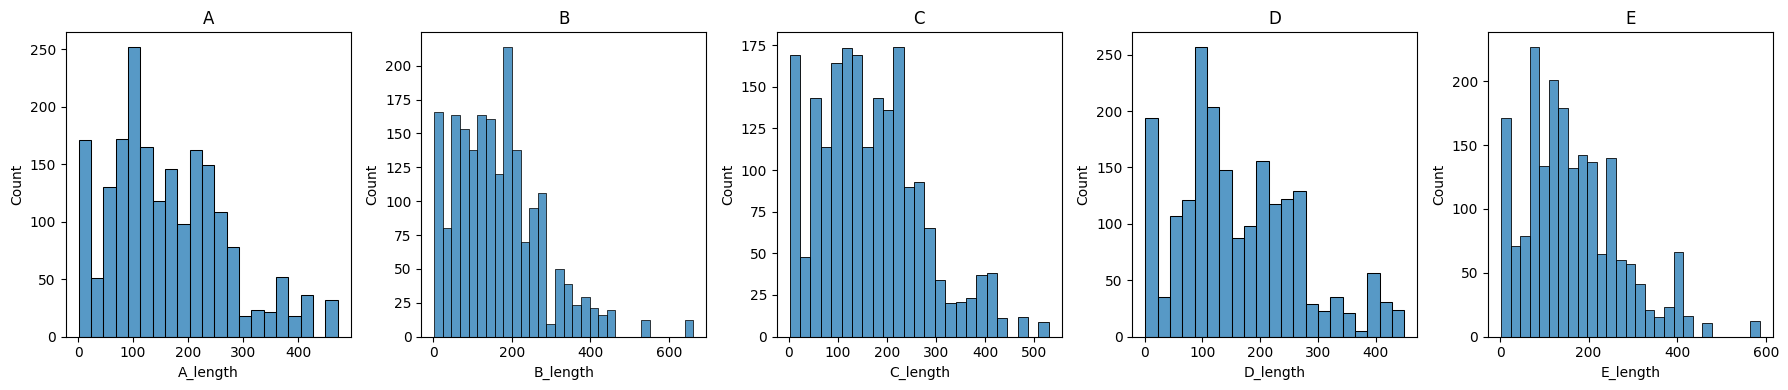

In [11]:
fig,ax=plt.subplots(1,5,figsize=(18,4))

for i,col in enumerate(['A','B','C','D','E']):

    sns.histplot(train[f"{col}_length"],ax=ax[i])

    ax[i].set_title(col)

plt.tight_layout()

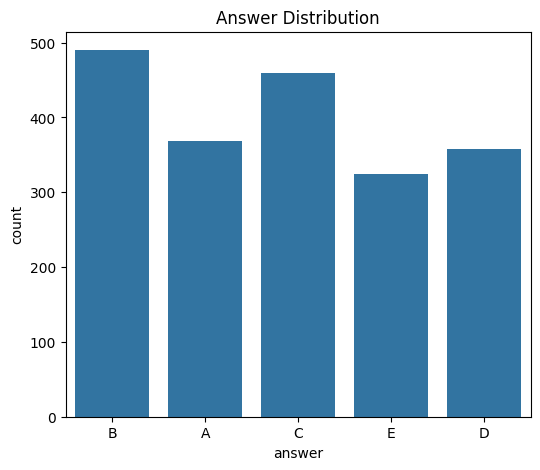

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(data=train,x='answer')

plt.title("Answer Distribution")

plt.show()

In [13]:
train.answer.value_counts(normalize=True)

answer
B    0.2450
C    0.2295
A    0.1845
D    0.1790
E    0.1620
Name: proportion, dtype: float64

In [14]:
def combine_text(row):

    return (
        row["prompt"]+
        " [SEP] A "+row["A"]+
        " [SEP] B "+row["B"]+
        " [SEP] C "+row["C"]+
        " [SEP] D "+row["D"]+
        " [SEP] E "+row["E"]
    )

In [15]:
train["combined"] = train.apply(combine_text,axis=1)

test["combined"] = test.apply(combine_text,axis=1)

In [16]:
train[["combined","answer"]].head()

,combined,answer
0,"Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options. [SEP] A Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time. [SEP] B Martin Heidegger believes tha...",B
1,"What is accelerator-based light-ion fusion? [SEP] A Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the electrodes. [SEP] B Accelerator-based light-ion f...",A
2,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options. [SEP] A Blueshifting [SEP] B Redshifting [SEP] C Reddening [SEP] D Whitening [SEP] E Yellowing,C
3,"Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully. [SEP] A Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time. [SEP] B Martin Heidegger believes that humans do n...",B
4,"Identify the correct statement: What is the concept of simultaneity in Einstein's book, Relativity? carefully. [SEP] A Simultaneity is relative, meaning that two events that appear simultaneous to an observer in a particular inertial reference frame need not be judged as simultaneous by a second observer in a different inertial frame of reference. [SEP] B Simultaneity is relative, meaning that two events that appear simultaneous to an observer in a particular inertial reference frame will al...",A


In [17]:
train_df, valid_df = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["answer"]
)

In [18]:
print(train_df.shape)
print(valid_df.shape)

(1600, 15)
(400, 15)


In [19]:
train_df.to_csv("train_processed.csv",index=False)

valid_df.to_csv("valid_processed.csv",index=False)

test.to_csv("test_processed.csv",index=False)